<h1><center>Computational Quantum Physics - PHYS 463</center></h1>

<p><center> <b>Lecturer:</b> <i>Prof. G. Carleo</i> </center><p>
    
<p><center> <b>Assistants: </b> <i>gabriel.pescia@epfl.ch, alessandro.sinibaldi@epfl.ch, clemens.giuliani@epfl.ch, linda.mauron@epfl.ch </i> </center><p>

# Exercise 8 - Template

In [ ]:
# Run this if you are on Windows and you don't want to use GPU
import os

os.environ["JAX_PLATFORM_NAME"] = "cpu"


In [2]:
import os
from typing import Any, Tuple
from flax import nnx
import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import netket as nk
import numpy as np


/home/francesco/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Setup

# Number of spins
N = 20
# Number of samples
Ns = 1024
# How many Markov chains to run in parallel
n_chains = 16
# How many samples to discard
n_discard = 128

# Graph
g = nk.graph.Chain(N, pbc=True)
# Hilbert space
hi = nk.hilbert.Spin(s=1 / 2, N=g.n_nodes)
# Hamiltonian
ha = nk.operator.Ising(hilbert=hi, graph=g, h=0.5)
# Sampler (single-spin flips)
sa = nk.sampler.MetropolisLocal(hi, n_chains=n_chains)
# Optimizer
op = nk.optimizer.Sgd(0.01)

# Folder where the figures are saved
os.makedirs("plots", exist_ok=True)

In [4]:
# Exact diagonalization (lanczos_ed returns an array of eigenvalues)
E0 = nk.exact.lanczos_ed(ha)[0]
print("Exact ground-state energy:", E0)

Exact ground-state energy: -21.270888306919243


In [5]:
class FFNN(nn.Module):
    # Number of hidden neurons per hidden layer
    width: int = 5
    # Number of hidden layers
    n_layers: int = 1

    @nn.compact
    def __call__(self, x):
        # x has shape (n_samples, N)
        # Hidden layers: x^(l) = ReLU(W^(l-1) x^(l-1) + b^(l))
        for _ in range(self.n_layers):
            x = nn.relu(nn.Dense(self.width)(x))
        # Output layer with a single unit: log psi(s) = ReLU(W x + b)
        x = nn.relu(nn.Dense(1)(x))
        # (n_samples, 1) -> (n_samples,)
        return x.squeeze(-1)

In [6]:
ma = FFNN(width=N // 4, n_layers=1)

## Problem 8.1 b) VMC with the MLP Ansatz, N = 20

In [7]:
# Variational state object
vs = nk.vqs.MCState(sa, ma, n_samples=Ns, n_discard_per_chain=n_discard)
# VMC optimization driver
vmc = nk.VMC(ha, op, variational_state=vs)

In [8]:
# Log the energy at every iteration to plot the convergence
log = nk.logging.RuntimeLog()
vmc.run(n_iter=1000, out=log)

100%|██████████| 1000/1000 [09:53<00:00,  1.69it/s, Energy=-21.235 ± 0.012 [σ²=0.116, R̂=1.0104]]  


(RuntimeLog():
  keys = ['acceptance', 'Energy'],)

In [9]:
ffnn_energy = vs.expect(ha)
error = abs((ffnn_energy.mean - E0) / E0)
print("Optimized energy and relative error: ", ffnn_energy, error)

Optimized energy and relative error:  -21.2281 ± 0.0072 [σ²=0.0570, R̂=1.0051] 0.0020127046397454425


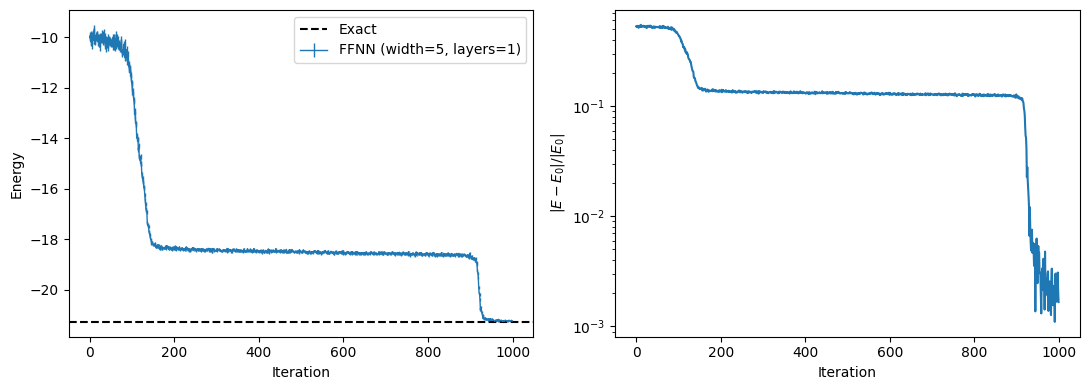

In [10]:
data = log.data["Energy"]
iters = np.asarray(data.iters)
E_mean = np.asarray(data.Mean.real)
E_sigma = np.asarray(data.Sigma)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.errorbar(iters, E_mean, yerr=E_sigma, lw=1, label=f"FFNN (width={ma.width}, layers={ma.n_layers})")
ax1.axhline(E0, color="k", ls="--", label="Exact")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Energy")
ax1.legend()

ax2.semilogy(iters, np.abs((E_mean - E0) / E0))
ax2.set_xlabel("Iteration")
ax2.set_ylabel(r"$|E - E_0| / |E_0|$")

fig.tight_layout()
fig.savefig("plots/ex08_1b_convergence.png", dpi=150)
plt.show()

### 8.1 b) Further diagnostics: a converged run vs a stuck run

Same Ansatz (1 hidden layer, width $N/4 = 5$), two different random initializations: seed 0 converges to $E \approx -25.1$, seed 1 gets stuck at the $E \approx -23.5$ plateau (see 8.1 c).
Besides the energy we monitor during the optimization:

- **Energy variance** $\langle H^2\rangle - \langle H\rangle^2$: zero for an exact eigenstate, so it measures the quality of the state without knowing $E_0$.
- **Statistical error** $\sigma$ of the energy estimate.
- **$\hat R$ (Gelman-Rubin)**: compares the variance between the Markov chains with the variance within each chain. $\hat R \approx 1$ means all chains sample the same distribution.
- **Autocorrelation time $\tau$** of the local energy along the chains: the number of Markov-chain steps between effectively independent samples.
- **Metropolis acceptance rate** of the single-spin flips.
- **Norm of the energy gradient and of the parameter vector.**

At the end of the optimization we draw longer chains (1024 samples per chain) and look at the autocorrelation function and the distribution of the local energy $E_{\rm loc}(s) = \langle s|H|\psi\rangle/\langle s|\psi\rangle$, and we compare the spin-spin correlations and the distribution of the staggered magnetization with the exact ground state.

In [12]:
from netket.operator.spin import sigmaz


def tree_norm(tree):
    """Euclidean norm of all the leaves of a pytree (e.g. the parameters or the gradient)."""
    return float(jnp.sqrt(sum(jnp.sum(jnp.abs(x) ** 2) for x in jax.tree_util.tree_leaves(tree))))


def staggered_magnetization(samples):
    """m_s = (1/N) sum_i (-1)^i s_i for each configuration (order parameter of the antiferromagnet)."""
    signs = (-1) ** np.arange(samples.shape[-1])
    return samples @ signs / samples.shape[-1]


def run_ffnn_diagnostics(width, n_layers, seed, n_iter=1000, n_samples_final=1024 * n_chains):
    """VMC optimization of the FFNN that also records gradient and parameter norms,
    followed by a longer sampling of the final state."""
    model = FFNN(width=width, n_layers=n_layers)
    vstate = nk.vqs.MCState(
        sa, model, n_samples=Ns, n_discard_per_chain=n_discard, seed=seed, sampler_seed=seed
    )
    driver = nk.VMC(ha, nk.optimizer.Sgd(0.01), variational_state=vstate)

    def record_norms(step, log_data, driver):
        # driver._dp is the energy gradient computed at this step (before the SGD update)
        log_data["grad_norm"] = tree_norm(driver._dp)
        log_data["param_norm"] = tree_norm(driver.state.parameters)
        return True

    run_log = nk.logging.RuntimeLog()
    driver.run(n_iter=n_iter, out=run_log, callback=record_norms, show_progress=False)

    # Longer Markov chains for the final state: local energies have shape (n_chains, samples per chain)
    vstate.n_samples = n_samples_final
    E_loc = np.asarray(vstate.local_estimators(ha).real)
    samples = np.asarray(vstate.samples).reshape(-1, N)
    E = vstate.expect(ha)
    corr = [float(vstate.expect(sigmaz(hi, 0) @ sigmaz(hi, r)).mean.real) for r in range(N // 2 + 1)]

    return {
        "seed": seed,
        "log": run_log.data,
        "E": float(E.mean.real),
        "E_err": float(E.error_of_mean),
        "var": float(E.variance),
        "tau": float(E.tau_corr),
        "E_loc": E_loc,
        "m_s": staggered_magnetization(samples),
        "corr": np.array(corr),
    }


diag_runs = [run_ffnn_diagnostics(N // 4, 1, seed) for seed in [0, 1]]
for d in diag_runs:
    print(
        f"seed={d['seed']}  E={d['E']:.4f} ± {d['E_err']:.4f}  var={d['var']:.3f}  "
        f"tau={d['tau']:.2f}  rel_err={abs((d['E'] - E0) / E0):.2e}"
    )

seed=0  E=-25.0600 ± 0.0092  var=1.157  tau=0.10  rel_err=1.69e-02
seed=1  E=-23.6803 ± 0.0145  var=2.993  tau=0.07  rel_err=7.10e-02


In [13]:
# Exact ground state for reference: spin-spin correlations and distribution of the staggered magnetization
_, psi0 = nk.exact.lanczos_ed(ha, compute_eigenvectors=True)
psi0 = psi0[:, 0]
corr_exact = np.array(
    [float(psi0 @ ((sigmaz(hi, 0) @ sigmaz(hi, r)).to_sparse() @ psi0)) for r in range(N // 2 + 1)]
)
# |psi0(s)|^2 as weights of the staggered magnetization of every basis state
m_s_all = staggered_magnetization(np.asarray(hi.all_states()))
p_exact = np.abs(psi0) ** 2

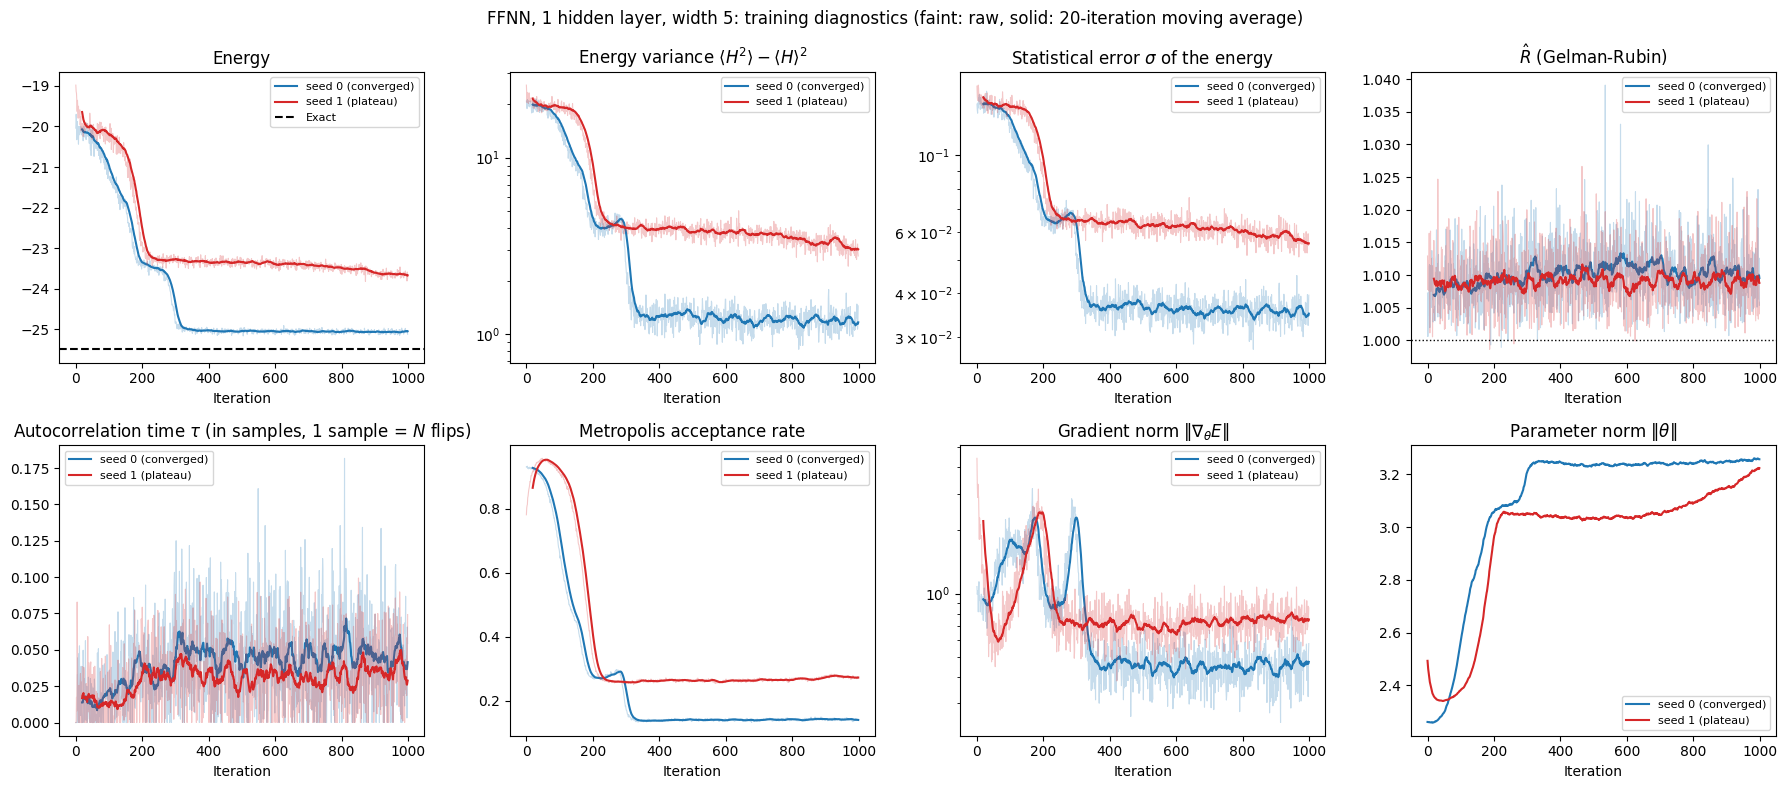

In [14]:
def running_mean(x, window=20):
    """Moving average, to make the trend of noisy quantities visible."""
    return np.convolve(x, np.ones(window) / window, mode="valid")


def plot_trace(ax, it, y, color, label, log=False, window=20):
    """Raw values (faint) and their moving average (solid)."""
    ax.plot(it, y, color=color, alpha=0.25, lw=0.8)
    ax.plot(it[window - 1 :], running_mean(y, window), color=color, lw=1.5, label=label)
    if log:
        ax.set_yscale("log")


run_colors = {0: "C0", 1: "C3"}
run_labels = {0: "seed 0 (converged)", 1: "seed 1 (plateau)"}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for d in diag_runs:
    en = d["log"]["Energy"]
    it = np.asarray(en.iters)
    c, lab = run_colors[d["seed"]], run_labels[d["seed"]]
    plot_trace(axes[0], it, np.asarray(en.Mean.real), c, lab)
    plot_trace(axes[1], it, np.asarray(en.Variance), c, lab, log=True)
    plot_trace(axes[2], it, np.asarray(en.Sigma), c, lab, log=True)
    plot_trace(axes[3], it, np.asarray(en.R_hat), c, lab)
    plot_trace(axes[4], it, np.asarray(en.TauCorr), c, lab)
    plot_trace(axes[5], np.asarray(d["log"]["acceptance"].iters), np.asarray(d["log"]["acceptance"].value), c, lab)
    plot_trace(axes[6], np.asarray(d["log"]["grad_norm"].iters), np.asarray(d["log"]["grad_norm"].value), c, lab, log=True)
    axes[7].plot(np.asarray(d["log"]["param_norm"].iters), np.asarray(d["log"]["param_norm"].value), color=c, lw=1.5, label=lab)

axes[0].axhline(E0, color="k", ls="--", label="Exact")
titles = [
    "Energy",
    r"Energy variance $\langle H^2\rangle - \langle H\rangle^2$",
    r"Statistical error $\sigma$ of the energy",
    r"$\hat R$ (Gelman-Rubin)",
    r"Autocorrelation time $\tau$ (in samples, 1 sample = $N$ flips)",
    "Metropolis acceptance rate",
    r"Gradient norm $\|\nabla_\theta E\|$",
    r"Parameter norm $\|\theta\|$",
]
for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_xlabel("Iteration")
    ax.legend(fontsize=8)
axes[3].axhline(1, color="k", ls=":", lw=1)

fig.suptitle("FFNN, 1 hidden layer, width 5: training diagnostics (faint: raw, solid: 20-iteration moving average)")
fig.tight_layout()
fig.savefig("plots/ex08_1b_training_diagnostics.png", dpi=150)
plt.show()

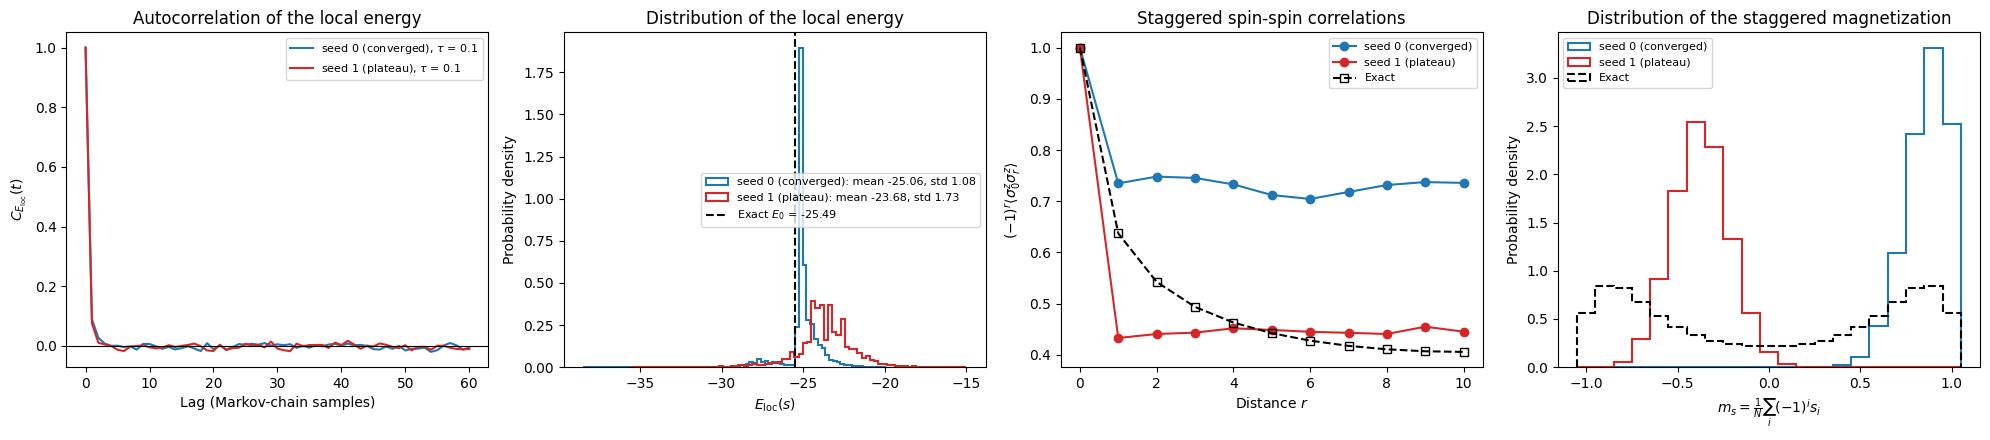

In [15]:
def autocorrelation(chains, max_lag=60):
    """Normalized autocorrelation function C(t) of a quantity along each Markov chain,
    averaged over the chains. chains has shape (n_chains, n_steps)."""
    x = chains - chains.mean(axis=1, keepdims=True)
    var = np.mean(x**2)
    return np.array([np.mean(x[:, : x.shape[1] - t] * x[:, t:]) / var for t in range(max_lag + 1)])


fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
lags = np.arange(61)
r = np.arange(N // 2 + 1)
for d in diag_runs:
    c, lab = run_colors[d["seed"]], run_labels[d["seed"]]
    # Autocorrelation of the local energy along the chains
    axes[0].plot(lags, autocorrelation(d["E_loc"], lags[-1]), color=c, label=f"{lab}, $\\tau$ = {d['tau']:.1f}")
    # Distribution of the local energy
    axes[1].hist(d["E_loc"].ravel(), bins=80, density=True, histtype="step", color=c, lw=1.5,
                 label=f"{lab}: mean {d['E']:.2f}, std {np.sqrt(d['var']):.2f}")
    # Staggered spin-spin correlations: (-1)^r <s_0 s_r>
    axes[2].plot(r, (-1) ** r * d["corr"], "o-", color=c, label=lab)
    # Distribution of the staggered magnetization
    axes[3].hist(d["m_s"], bins=np.linspace(-1.05, 1.05, N + 2), density=True, histtype="step", color=c, lw=1.5, label=lab)

axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xlabel("Lag (Markov-chain samples)")
axes[0].set_ylabel(r"$C_{E_{\rm loc}}(t)$")
axes[0].set_title("Autocorrelation of the local energy")

axes[1].axvline(E0, color="k", ls="--", label=f"Exact $E_0$ = {E0:.2f}")
axes[1].set_xlabel(r"$E_{\rm loc}(s)$")
axes[1].set_ylabel("Probability density")
axes[1].set_title("Distribution of the local energy")

axes[2].plot(r, (-1) ** r * corr_exact, "k--", marker="s", mfc="none", label="Exact")
axes[2].set_xlabel("Distance $r$")
axes[2].set_ylabel(r"$(-1)^r \langle\sigma^z_0 \sigma^z_r\rangle$")
axes[2].set_title("Staggered spin-spin correlations")

axes[3].hist(m_s_all, bins=np.linspace(-1.05, 1.05, N + 2), weights=p_exact, density=True, histtype="step",
             color="k", ls="--", lw=1.5, label="Exact")
axes[3].set_xlabel(r"$m_s = \frac{1}{N}\sum_i (-1)^i s_i$")
axes[3].set_ylabel("Probability density")
axes[3].set_title("Distribution of the staggered magnetization")

for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("plots/ex08_1b_final_state.png", dpi=150)
plt.show()

#### Discussion of the diagnostics

Final states (16384 samples): seed 0 gives $E = -25.060 \pm 0.009$ (variance 1.16), seed 1 gives $E = -23.673 \pm 0.015$ (variance 3.05); exact $E_0 = -25.491$.

**The sampling is not the problem.** For both runs $\hat R \approx 1.01$ during the whole optimization and the autocorrelation time is $\tau \approx 0.1$ samples: the autocorrelation function of $E_{\rm loc}$ drops to $\approx 0.08$ after one sample and to zero after two. One sample is a sweep of $N$ single-spin flip proposals, which is enough to decorrelate the chain. The error bars of the energy are therefore reliable, and the difference between the two runs comes from the variational state, not from the Monte Carlo.

**The energy variance tells the two runs apart without knowing $E_0$.** It drops from $\approx 20$ to $\approx 1.2$ for the converged run and only to $\approx 3$ on the plateau. The statistical error $\sigma$ follows the variance.

**Acceptance rate.** At the start $\psi$ is almost constant and nearly every spin flip is accepted (≈ 0.9). As the network learns antiferromagnetic order, flipping a spin creates two domain walls and becomes unlikely: the acceptance drops to 0.14 for the converged state and to 0.27 on the plateau, which is less ordered.

**Gradient and parameters.** The plateau is not a point where the gradient vanishes: its gradient norm stays *larger* than for the converged run, and the parameter norm keeps growing slowly while the energy creeps down (−23.3 → −23.7). SGD with a fixed learning rate of 0.01 just moves very slowly along a flat direction. The converged run shows a second peak in the gradient norm at iteration ≈ 300, exactly when it leaves the plateau.

**Correlations and symmetry breaking.** The exact ground state at the critical point has staggered correlations that decay with distance, from 0.64 at $r = 1$ to 0.41 at $r = 10$, and a staggered magnetization distribution that is symmetric under $m_s \to -m_s$ (the $\mathbb{Z}_2$ symmetry $s \to -s$ of the Hamiltonian). Neither network respects this symmetry, since nothing in the FFNN enforces $\psi(s) = \psi(-s)$: each one picks a sector.

The nearest-neighbour correlation fixes the Ising part of the energy, $J\sum_i\langle\sigma^z_i\sigma^z_{i+1}\rangle = N J \langle\sigma^z_0\sigma^z_1\rangle$, and the rest comes from the transverse field:

| | $\langle\sigma^z_0\sigma^z_1\rangle$ | Ising energy | transverse-field energy | total |
|---|---|---|---|---|
| exact | −0.637 | −12.75 | −12.74 | −25.49 |
| seed 0 (converged) | −0.735 | −14.70 | −10.36 | −25.06 |
| seed 1 (plateau) | −0.428 | −8.56 | −15.11 | −23.67 |

- The *converged* FFNN is **too ordered**: all its samples sit in one Néel sector ($\langle m_s\rangle = 0.86$) and its correlations do not decay at all (≈ 0.73 for every $r \ge 1$), i.e. it describes a long-range ordered antiferromagnet. It gains 2.0 in Ising energy and loses 2.4 in transverse-field energy with respect to the exact state.
- The *plateau* state is **not ordered enough**: $\langle m_s\rangle = -0.37$ and correlations of only ≈ 0.44 at all distances. It gains 2.4 in transverse-field energy but loses 4.2 in Ising energy.

In both cases the correlations are flat in $r$ instead of decaying, so a small fully connected network represents something like a mean-field state with one global level of order. A symmetric Ansatz, e.g. $\log\psi(s) = \log\left(e^{f(s)} + e^{f(-s)}\right)$, would restore the $\mathbb{Z}_2$ symmetry, and the translation-invariant CNN of 8.2 builds in the other symmetry of the chain.

## Problem 8.1 c) Dependence on the width and depth of the network

In [16]:
def run_ffnn(width, n_layers, n_iter=1000, seed=0):
    """Optimize an FFNN Ansatz with VMC and return its final energy and training log."""
    model = FFNN(width=width, n_layers=n_layers)
    # Fixed seeds so that only the architecture changes between runs
    vstate = nk.vqs.MCState(
        sa, model, n_samples=Ns, n_discard_per_chain=n_discard, seed=seed, sampler_seed=seed
    )
    driver = nk.VMC(ha, nk.optimizer.Sgd(0.01), variational_state=vstate)
    run_log = nk.logging.RuntimeLog()
    driver.run(n_iter=n_iter, out=run_log, show_progress=False)

    E = vstate.expect(ha)
    E_mean = float(E.mean.real)
    return {
        "width": width,
        "n_layers": n_layers,
        "n_params": vstate.n_parameters,
        "E": E_mean,
        "E_err": float(E.error_of_mean),
        "var": float(E.variance),
        "rel_err": abs((E_mean - E0) / E0),
        "log": run_log.data["Energy"],
    }

In [ ]:
# Widths N/4, N/2, N, 2N and 1 to 3 hidden layers (this takes a while on CPU).
# With plain SGD the outcome depends strongly on the random initialization
# (some runs get stuck in a local minimum), so every architecture is run with several seeds.
widths = [N // 4, N // 2, N, 2 * N]
depths = [1, 2, 3]
seeds = [0, 1, 2]

results = []
for n_layers in depths:
    for width in widths:
        for seed in seeds:
            r = run_ffnn(width, n_layers, seed=seed)
            r["seed"] = seed
            results.append(r)
            print(
                f"layers={n_layers} width={width:3d} seed={seed} params={r['n_params']:5d}  "
                f"E={r['E']:.4f} ± {r['E_err']:.4f}  var={r['var']:.3f}  rel_err={r['rel_err']:.2e}"
            )

layers=1 width=  5 seed=0 params=  111  E=-25.1229 ± 0.0337  var=1.146  rel_err=1.44e-02


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, n_layers in enumerate(depths):
    color = f"C{i}"
    label = f"{n_layers} hidden layer" + ("s" if n_layers > 1 else "")
    rs = [r for r in results if r["n_layers"] == n_layers]
    # Best run over seeds (solid line) and every individual run (faint points)
    best = [min((r for r in rs if r["width"] == w), key=lambda r: r["rel_err"]) for w in widths]
    axes[0].semilogy(widths, [b["rel_err"] for b in best], "o-", color=color, label=label)
    axes[0].semilogy([r["width"] for r in rs], [r["rel_err"] for r in rs], "x", color=color, alpha=0.4)
    axes[1].loglog([b["n_params"] for b in best], [b["rel_err"] for b in best], "o-", color=color, label=label)

axes[0].set_xlabel("Width (hidden neurons per layer)")
axes[0].set_xticks(widths)
axes[0].set_title("Lines: best of seeds, crosses: all runs")
axes[1].set_xlabel("Number of variational parameters")
axes[1].set_title("Best of seeds")
for ax in axes[:2]:
    ax.set_ylabel(r"$|E - E_0| / |E_0|$")
    ax.legend()

# Convergence of all one-hidden-layer runs of width N/4: same Ansatz, different seeds
for r in results:
    if r["n_layers"] == 1 and r["width"] == widths[0]:
        axes[2].plot(r["log"].iters, r["log"].Mean.real, lw=1, label=f"seed={r['seed']}")
axes[2].axhline(E0, color="k", ls="--", label="Exact")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Energy")
axes[2].set_title(f"1 hidden layer, width {widths[0]}")
axes[2].legend()

fig.tight_layout()
fig.savefig("plots/ex08_1c_width_depth.png", dpi=150)
plt.show()

### Discussion

Exact energy: $E_0 = -25.491$. Relative error after 1000 SGD iterations (learning rate 0.01), for seeds 0 / 1 / 2:

| hidden layers | width 5 | width 10 | width 20 | width 40 |
|---|---|---|---|---|
| 1 | 1.4 / 6.8 / 7.2 % | 7.6 / 1.5 / 6.3 % | 1.3 / 1.3 / 5.8 % | 1.5 / 1.5 / 1.3 % |
| 2 | 1.6 / 6.9 / 5.8 % | 8.0 / 1.5 / 5.5 % | 21 / 1.7 / 1.3 % | 21 / 1.2 / 1.3 % |
| 3 | 1.6 / 8.0 / 1.5 % | 1.4 / 5.2 / 5.6 % | 1.1 / 1.5 / 21 % | 1.1 / 22 / 1.1 % |

**The runs end in one of three places, and which one depends mostly on the random initialization, not on the architecture:**

1. $E \approx -25.1$ to $-25.2$ (relative error 1.1–1.7 %, variance ≈ 1.1): the optimization worked. 20 of the 36 runs.
2. $E \approx -23.5$ to $-24.2$ (relative error 5–8 %, variance ≈ 3): a plateau. The right panel shows that a run can sit there for a long time and then escape (seed 0 leaves it around iteration 300). With plain SGD and 1000 iterations, 12 runs never escaped.
3. $E \approx -20$ (relative error ≈ 21 %, variance ≈ 20): these runs never move away from their starting energy. $-20 = -\Gamma N$ is the energy of a constant wave function, for which $\langle\sigma^z_i\sigma^z_{i+1}\rangle = 0$. This means the output ReLU is zero for (nearly) all sampled configurations: $\log\psi = 0$, and its gradient vanishes, so SGD cannot move. This only happened for the deep and wide networks (≥ 2 layers, width ≥ 20).

**Width.** For one hidden layer, the best energy improves only slightly with width, from 1.4 % at width $N/4$ to 1.3 % at width $2N$. Wider networks do make the optimization more reliable: at width 40, all three seeds converge. A single hidden layer of width 5 (111 parameters) can already reach ≈ 1.4 %, so the error is not limited by the size of the network but by the optimization (plain SGD, fixed learning rate, 1000 iterations) and by Monte Carlo noise.

**Depth.** Deeper networks reach slightly lower energies when they converge. The best runs go from 1.3 % (1 layer) to 1.2 % (2 layers) to 1.1 % (3 layers), all at width 40. The gain is small compared to the spread between seeds, and deep networks fail more often: they add the dead-output failure mode on top of the plateau. More parameters make the Ansatz more expressive but harder to train with plain SGD. Stochastic reconfiguration (`preconditioner=nk.optimizer.SR(...)`) or a different output layer (e.g. summing the last hidden layer instead of a single ReLU unit) would likely remove most of these failures.

## Problem 8.2 (Optional) Convolutional Neural Network Ansatz

Each hidden layer is a 1D convolution with circular padding, which respects the periodic boundary conditions, followed by a ReLU.
The feature maps are then pooled over the lattice sites and summed over the features:

$$\log\psi(s) = \sum_{f} \operatorname{pool}_{i}\, x^{(L)}_{i,f}, \qquad \operatorname{pool} \in \{\text{sum}, \text{mean}, \text{max}\}.$$

Because the same filter is applied at every site and the pooling runs over all sites, $\log\psi(Ts) = \log\psi(s)$ for every translation $T$ of the chain.

In [ ]:
class CNN(nn.Module):
    # Number of filters (output channels) per convolutional layer
    features: int = 4
    # Size of the convolution filter (number of neighbouring sites it sees)
    kernel_size: int = 3
    # Number of convolutional layers
    n_layers: int = 1
    # Pooling over the lattice sites: jnp.sum, jnp.mean or jnp.max
    pooling: Any = jnp.sum

    @nn.compact
    def __call__(self, x):
        # (n_samples, N) -> (n_samples, N, 1): one input channel per site
        x = x.reshape(x.shape[0], -1, 1)
        for _ in range(self.n_layers):
            # Circular padding implements the periodic boundary conditions
            x = nn.Conv(self.features, kernel_size=(self.kernel_size,), padding="CIRCULAR")(x)
            x = nn.relu(x)
        # Pool over the sites, then sum over the features: (n_samples, N, features) -> (n_samples,)
        return jnp.sum(self.pooling(x, axis=1), axis=-1)


# Check the output shape and the translation invariance
cnn = CNN()
x_test = hi.random_state(jax.random.PRNGKey(0), 5)
p_test = cnn.init(jax.random.PRNGKey(0), x_test)
print(cnn.apply(p_test, x_test).shape)
print(jnp.allclose(cnn.apply(p_test, x_test), cnn.apply(p_test, jnp.roll(x_test, 3, axis=1)), atol=1e-5))

In [ ]:
def run_cnn(kernel_size, pooling, features=4, n_iter=1000, seed=0):
    """Optimize a CNN Ansatz with VMC (same settings as the MLP) and return its final energy and log."""
    model = CNN(features=features, kernel_size=kernel_size, pooling=pooling)
    vstate = nk.vqs.MCState(
        sa, model, n_samples=Ns, n_discard_per_chain=n_discard, seed=seed, sampler_seed=seed
    )
    driver = nk.VMC(ha, nk.optimizer.Sgd(0.01), variational_state=vstate)
    run_log = nk.logging.RuntimeLog()
    driver.run(n_iter=n_iter, out=run_log, show_progress=False)

    E = vstate.expect(ha)
    E_mean = float(E.mean.real)
    return {
        "kernel_size": kernel_size,
        "pooling": pooling.__name__,
        "n_params": vstate.n_parameters,
        "E": E_mean,
        "E_err": float(E.error_of_mean),
        "var": float(E.variance),
        "rel_err": abs((E_mean - E0) / E0),
        "log": run_log.data["Energy"],
    }


# One CNN run takes about 4-5 minutes on CPU.
# QUICK = True runs only 3 representative configurations (~15 min):
#   sum pooling / filter 5, mean pooling / filter 9 (the best one), max pooling / filter 9.
# QUICK = False runs the full scan used in the discussion below (12 runs, ~50 min):
#   filter sizes from nearest neighbours up to (almost) the whole chain, three pooling functions.
QUICK = True

if QUICK:
    kernel_sizes = [5, 9]
    configs = [(5, jnp.sum), (9, jnp.mean), (9, jnp.max)]
else:
    kernel_sizes = [3, 5, 9, 15]
    configs = [(k, pooling) for pooling in [jnp.sum, jnp.mean, jnp.max] for k in kernel_sizes]

cnn_results = []
for k, pooling in configs:
    r = run_cnn(k, pooling)
    cnn_results.append(r)
    print(
        f"pool={r['pooling']:4s} kernel={k:2d} params={r['n_params']:3d}  "
        f"E={r['E']:.4f} ± {r['E_err']:.4f}  var={r['var']:.3f}  rel_err={r['rel_err']:.2e}"
    )

In [ ]:
# Comparison with the MLP: best run of the 8.1 c scan if it was run, otherwise the 8.1 b run
if "results" in globals():
    mlp_best = min(results, key=lambda r: r["rel_err"])
    mlp_label = f"MLP best of 8.1 c ({mlp_best['n_layers']} layers x {mlp_best['width']})"
    mlp_rows = [(mlp_label, mlp_best["n_params"], mlp_best["E"], mlp_best["rel_err"])]
else:
    mlp_rows = [(f"MLP 8.1 b (1 layer x {ma.width})", vs.n_parameters, float(ffnn_energy.mean.real), float(error))]

cnn_rows = [
    (f"CNN {r['pooling']} pooling, filter {r['kernel_size']}", r["n_params"], r["E"], r["rel_err"])
    for r in cnn_results
]

print(f"{'Ansatz':38s} {'params':>6s} {'energy':>9s} {'rel. error':>10s}")
for name, n_par, E, err in mlp_rows + cnn_rows:
    print(f"{name:38s} {n_par:6d} {E:9.4f} {100 * err:9.2f} %")
print(f"{'Exact':38s} {'':6s} {E0:9.4f}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
# Same color for each pooling function in every panel
pool_colors = {"sum": "C0", "mean": "C1", "max": "C2"}

for pool_name in ["sum", "mean", "max"]:
    rs = [r for r in cnn_results if r["pooling"] == pool_name]
    axes[0].semilogy([r["kernel_size"] for r in rs], [r["rel_err"] for r in rs], "o-", color=pool_colors[pool_name], label=f"{pool_name} pooling")
axes[0].set_xlabel("Filter size")
axes[0].set_xticks(kernel_sizes)
axes[0].set_ylabel(r"$|E - E_0| / |E_0|$")
axes[0].set_title("CNN")
axes[0].legend()

# CNN vs MLP as a function of the number of parameters (all runs of 8.1 c, or the 8.1 b run)
if "results" in globals():
    axes[1].loglog([r["n_params"] for r in results], [r["rel_err"] for r in results], "x", color="gray", label="MLP (all runs)")
else:
    axes[1].loglog([vs.n_parameters], [float(error)], "x", color="gray", label="MLP (8.1 b)")
axes[1].loglog([r["n_params"] for r in cnn_results], [r["rel_err"] for r in cnn_results], "o", color="C3", label="CNN (all runs)")
axes[1].set_xlabel("Number of variational parameters")
axes[1].set_ylabel(r"$|E - E_0| / |E_0|$")
axes[1].set_title("CNN vs MLP")
axes[1].legend()

# Convergence for the pooling functions at filter size 9
for r in cnn_results:
    if r["kernel_size"] == 9:
        axes[2].plot(r["log"].iters, r["log"].Mean.real, lw=1, color=pool_colors[r["pooling"]], label=f"{r['pooling']} pooling")
axes[2].axhline(E0, color="k", ls="--", label="Exact")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Energy")
axes[2].set_title("CNN, filter size 9")
axes[2].legend()

fig.tight_layout()
fig.savefig("plots/ex08_2_cnn_quick.png" if QUICK else "plots/ex08_2_cnn.png", dpi=150)
plt.show()

### Discussion

CNN with 4 filters and one convolutional layer, same optimizer as the MLP (SGD, learning rate 0.01, 1000 iterations, seed 0). Relative error with respect to $E_0 = -25.491$:

| pooling | filter 3 (16 par.) | filter 5 (24 par.) | filter 9 (40 par.) | filter 15 (64 par.) |
|---|---|---|---|---|
| sum | 0.79 % | 0.72 % | diverged ($E = +20$) | diverged ($E = +20$) |
| mean | 1.28 % | 0.53 % | **0.14 %** | 0.54 % (still decreasing) |
| max | 21 % | 15 % | 8.5 % | 4.9 % |

**CNN vs MLP.** The best CNN ($E = -25.454 \pm 0.024$, 0.14 %, 40 parameters) is about 8 times more accurate than the best MLP (1.1 %, 4161 parameters), with 100 times fewer parameters. Even the smallest CNN (16 parameters, sum pooling) beats every MLP run. The reason is symmetry. The ground state of the periodic chain is translation invariant. The CNN has this symmetry built in: the same filter is applied at every site and the pooling runs over all sites, so $\psi(Ts) = \psi(s)$ exactly. It only has to learn one local pattern of correlations. The MLP has no notion of translations: it has to learn the same pattern separately at each position, which costs many more parameters and makes the optimization harder (plateaus and dead units in 8.1 c).

**Filter size.** The filter size sets the range of spin correlations that one convolution can see. The chain is at the critical point $\Gamma = J$, where correlations decay slowly, so larger filters help: with mean pooling the error goes from 1.28 % (filter 3) to 0.53 % (5) to 0.14 % (9). At filter size 15 the energy was still decreasing after 1000 iterations (−25.12 at iteration 500, −25.38 at iteration 1000), so it is limited by the number of iterations, not by the Ansatz.

**Pooling.**
- *Sum* pooling gives $\log\psi$ that is $N = 20$ times larger than *mean* pooling, and so do its gradients. With the same learning rate, sum pooling therefore takes much larger steps. This converges fastest for small filters, but for filters 9 and 15 one step is too large: the energy jumps from about $-21$ to $+20$ in a single iteration (iteration 102 for filter 9, right panel). The wave function then collapses onto a single ferromagnetic configuration: $E = +JN = +20$ with zero variance. From there, all samples are the same configuration and the gradient is zero, so the optimization can never recover. A smaller learning rate would avoid this.
- *Mean* pooling is the most stable, and gives the best results as soon as the filter is large enough. For filter 3 it is slower, because its steps are 20 times smaller.
- *Max* pooling is the worst. $\log\psi$ only depends on the largest activation of each filter, i.e. on a single site per filter, so the wave function carries very little information about the rest of the configuration, and the gradient only reaches the parameters through that one site. Its results start at about $-20$, the energy of a constant wave function, and improve with the filter size because each activation then sees more of the chain.

These results use a single seed per configuration. Section 8.1 c showed that the seed can matter a lot for the MLP, so small differences (e.g. 0.53 % vs 0.54 %) should not be over-interpreted.